In [16]:
import numpy as np
import pandas as pd
import os
import re
import glob
from pathlib import Path
import seaborn


# Results using Karambola

In [3]:
# Define datasets, center types, resolutions, and subfolders
datasets = ['aspect_ratio']
# center_types = ['com', 'cos', 'coc', 'cov']
subfolders = ['cuboid', 'spherocylinder', 'ellipsoid', 'cylinder']

# Base paths
base_results_path = '../../data/results/basic_shapes'
base_output_path = '../../data/karambola_results/basic_shapes'

In [4]:
# Function to calculate beta value (min/max of eigenvalues)
def calculate_beta(eigenvalues):
    return min(np.abs(eigenvalues)) / max(np.abs(eigenvalues))

In [5]:
def round_floats(df, decimals=5):
    float_cols = df.select_dtypes(include='float').columns
    df[float_cols] = df[float_cols].round(decimals)
    df[float_cols] = df[float_cols].replace(0.0, 1e-5)
    return df

Remove process_symmetric_columns when pushing to ishiharlab repo

In [111]:
# def process_symmetric_columns(dataset, res, overwrite=True):
def process_symmetric_columns(df):

    """
    Process a DataFrame to identify and drop redundant symmetric columns based on a pattern.
    
    Parameters:
    - dataset (str): Name of the dataset (e.g., 'adrenal3d', 'vessel3d').
    - res (str): Resolution (e.g., '28', '64').
    - overwrite (bool): If True, overwrite the original CSV file. Default is True.
    
    Returns:
    - pd.DataFrame: Processed DataFrame with redundant columns dropped.
    """
    pattern = re.compile(r"^(w\d{3})_(\d)(\d)$")  # matches like w020_12, w102_21, etc.
    
    # Construct file path
    # path = f"./data/medmnist/{dataset}/{dataset}_{res}/minkowski_tensors_with_eigen_vals.csv"
    # df = pd.read_csv(path)
    # print(f"\n{dataset}_{res} — starting with {len(df.columns)} columns")
    print(f"Starting with {len(df.columns)} columns")


    # Identify symmetric column pairs
    pairs = []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            symmetric_col = f"{tensor}_{j}{i}"
            if (
                symmetric_col in df.columns 
                and (col, symmetric_col) not in pairs 
                and (symmetric_col, col) not in pairs
            ):
                pairs.append((col, symmetric_col))

    # Check for redundant columns
    cols_to_drop = []
    for col1, col2 in pairs:
        m1 = pattern.match(col1)
        if not m1:
            continue
        _, i, j = m1.groups()

        # Skip diagonal entries (i == j)
        if i == j:
            continue

        all_equal = (df[col1] == df[col2]).all()
        if all_equal:
            print(f"{col1} == {col2} for all rows ✅ — dropping {col2}")
            cols_to_drop.append(col2)
        else:
            diff_rows = (df[col1] != df[col2]).sum()
            print(f"{col1} != {col2} in {diff_rows} rows ❌")

    # Drop redundant columns
    df = df.drop(columns=cols_to_drop)
    print(f"After drop: {len(df.columns)} columns remain")
    
    # Optionally overwrite the original file
    # if overwrite:
    #     df.to_csv(path, index=False)
    
    return df

In [112]:
# Process each dataset, center type, and resolution
for dataset in datasets:
    # Define paths
    parent_directory_path = os.path.join(base_results_path, f'{dataset}')
    output_directory = os.path.join(base_output_path, f'{dataset}')
    
    # Check if input directory exists
    if not os.path.exists(parent_directory_path):
        print(f'Skipping: Directory {parent_directory_path} does not exist')
        continue

    # Initialize results dictionary for scalar tensors
    results = {
        'image_num': [],
        'label_mapped': [],
        'w000': [], 'w100': [], 'w200': [], 'w300': [],
        'w010_0': [], 'w010_1': [], 'w010_2': [],
        'w110_0': [], 'w110_1': [], 'w110_2': [],
        'w210_0': [], 'w210_1': [], 'w210_2': [],
        'w310_0': [], 'w310_1': [], 'w310_2': [],
        'w020_00': [], 'w020_01': [], 'w020_02': [],
        'w020_10': [], 'w020_11': [], 'w020_12': [],
        'w020_20': [], 'w020_21': [], 'w020_22': [],
        'w120_00': [], 'w120_01': [], 'w120_02': [],
        'w120_10': [], 'w120_11': [], 'w120_12': [],
        'w120_20': [], 'w120_21': [], 'w120_22': [],
        'w220_00': [], 'w220_01': [], 'w220_02': [],
        'w220_10': [], 'w220_11': [], 'w220_12': [],
        'w220_20': [], 'w220_21': [], 'w220_22': [],
        'w320_00': [], 'w320_01': [], 'w320_02': [],
        'w320_10': [], 'w320_11': [], 'w320_12': [],
        'w320_20': [], 'w320_21': [], 'w320_22': [],
        'w102_00': [], 'w102_01': [], 'w102_02': [],
        'w102_10': [], 'w102_11': [], 'w102_12': [],
        'w102_20': [], 'w102_21': [], 'w102_22': [],
        'w202_00': [], 'w202_01': [], 'w202_02': [],
        'w202_10': [], 'w202_11': [], 'w202_12': [],
        'w202_20': [], 'w202_21': [], 'w202_22': [],
        'beta_w020': [], 'beta_w102': [], 'beta_w120': [],
        'beta_w202': [], 'beta_w220': [], 'beta_w320': [],
        'w020_EVal1': [], 'w020_EVal2': [], 'w020_EVal3': [],
        'w102_EVal1': [], 'w102_EVal2': [], 'w102_EVal3': [],
        'w120_EVal1': [], 'w120_EVal2': [], 'w120_EVal3': [],
        'w202_EVal1': [], 'w202_EVal2': [], 'w202_EVal3': [],
        'w220_EVal1': [], 'w220_EVal2': [], 'w220_EVal3': [],
        'w320_EVal1': [], 'w320_EVal2': [], 'w320_EVal3': []
    }

    # Process each subfolder
    for subfolder in subfolders:
        subfolder_path = os.path.join(parent_directory_path, subfolder)
        if not os.path.exists(subfolder_path):
            print(f'Skipping subfolder {subfolder}: Directory does not exist')
            continue

        # Find all folders within the subfolder
        folder_pattern = os.path.join(subfolder_path, '*')
        folders = glob.glob(folder_pattern)

        for folder in folders:
            if not os.path.isdir(folder):
                continue

            # Extract folder name components
            folder_name = os.path.basename(folder)
            try:
                image_id = folder_name
                image_id = str(image_id) # CellId includes string. 
            except ValueError:
                print(f'Skipping folder {folder_name} in {subfolder}: Invalid name format')
                continue

            # Initialize data for this folder
            folder_data = {
                'w000': None, 'w100': None, 'w200': None, 'w300': None,
                'w010': [None, None, None], 'w110': [None, None, None],
                'w210': [None, None, None], 'w310': [None, None, None],
                'w020': [[None, None, None], [None, None, None], [None, None, None]],
                'w120': [[None, None, None], [None, None, None], [None, None, None]],
                'w220': [[None, None, None], [None, None, None], [None, None, None]],
                'w320': [[None, None, None], [None, None, None], [None, None, None]],
                'w102': [[None, None, None], [None, None, None], [None, None, None]],
                'w202': [[None, None, None], [None, None, None], [None, None, None]],
                'w020_eig': [None, None, None], 'w102_eig': [None, None, None],
                'w120_eig': [None, None, None], 'w202_eig': [None, None, None],
                'w220_eig': [None, None, None], 'w320_eig': [None, None, None]
            }

            # Process scalar tensors (w000_w100_w200_w300)
            file_path = os.path.join(folder, 'w000_w100_w200_w300')
            if os.path.exists(file_path):
                with open(file_path, 'r') as file:
                    for line in file:
                        if line.startswith('#'):
                            continue
                        columns = line.split()
                        if len(columns) > 3:
                            value = float(columns[1])
                            name = columns[2]
                            if name in folder_data:
                                folder_data[name] = value

            # Process vector tensors (w010_w110_w210_w310)
            file_path = os.path.join(folder, 'w010_w110_w210_w310')
            if os.path.exists(file_path):
                with open(file_path, 'r') as file:
                    for line in file:
                        if line.startswith('#'):
                            continue
                        columns = line.split()
                        if len(columns) > 5:
                            vx, vy, vz = float(columns[1]), float(columns[2]), float(columns[3])
                            name = columns[4]
                            if name in folder_data:
                                folder_data[name] = [vx, vy, vz]

            # Process matrix tensors (w020, w120, w220, w320, w102, w202)
            for tensor in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                file_path = os.path.join(folder, tensor)
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#'):
                                continue
                            columns = line.split()
                            if len(columns) > 10:
                                m00 = float(columns[1])
                                m01 = float(columns[2])
                                m02 = float(columns[3])
                                m10 = float(columns[4])
                                m11 = float(columns[5])
                                m12 = float(columns[6])
                                m20 = float(columns[7])
                                m21 = float(columns[8])
                                m22 = float(columns[9])
                                name = columns[10]
                                if name == tensor:
                                    folder_data[name] = [[m00, m01, m02], [m10, m11, m12], [m20, m21, m22]]

            # Process eigenvalue files
            for eigsys_file in ['w020_eigsys', 'w102_eigsys', 'w120_eigsys', 'w202_eigsys', 'w220_eigsys', 'w320_eigsys']:
                file_path = os.path.join(folder, eigsys_file)
                if os.path.exists(file_path):
                    with open(file_path, 'r') as file:
                        for line in file:
                            if line.startswith('#') or 'ALL' not in line:
                                continue
                            parts = line.split()
                            EVal1 = float(parts[1])
                            EVal2 = float(parts[5])
                            EVal3 = float(parts[9])
                            folder_data[eigsys_file.split('_')[0] + '_eig'] = [EVal1, EVal2, EVal3]

            # Append data to results
            results['image_num'].append(image_id)
            # results['label'].append(label)
            results['label_mapped'].append(subfolder)
            for key in ['w000', 'w100', 'w200', 'w300']:
                results[key].append(folder_data[key])
            for key in ['w010', 'w110', 'w210', 'w310']:
                for i in range(3):
                    results[f'{key}_{i}'].append(folder_data[key][i])
            for key in ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']:
                for i in range(3):
                    for j in range(3):
                        results[f'{key}_{i}{j}'].append(folder_data[key][i][j])
            for key in ['w020', 'w102', 'w120', 'w202', 'w220', 'w320']:
                eigenvalues = folder_data[key + '_eig']
                results[f'beta_{key}'].append(calculate_beta(eigenvalues) if all(v is not None for v in eigenvalues) else None)
                for i, eval_name in enumerate(['EVal1', 'EVal2', 'EVal3']):
                    results[f'{key}_{eval_name}'].append(eigenvalues[i])

        # Create DataFrame
        df = pd.DataFrame(results)
        # df = round_floats(df)
        df = process_symmetric_columns(df)


        # Save to CSV
        df_path = Path(os.path.join(output_directory, 'minkowski_tensors_with_eigen_vals.csv'))
        df_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(df_path, index=False)
        print(f'Saved DataFrame to {df_path}')

Starting with 96 columns
w020_01 == w020_10 for all rows ✅ — dropping w020_10
w020_02 == w020_20 for all rows ✅ — dropping w020_20
w020_12 == w020_21 for all rows ✅ — dropping w020_21
w120_01 == w120_10 for all rows ✅ — dropping w120_10
w120_02 == w120_20 for all rows ✅ — dropping w120_20
w120_12 == w120_21 for all rows ✅ — dropping w120_21
w220_01 == w220_10 for all rows ✅ — dropping w220_10
w220_02 == w220_20 for all rows ✅ — dropping w220_20
w220_12 == w220_21 for all rows ✅ — dropping w220_21
w320_01 == w320_10 for all rows ✅ — dropping w320_10
w320_02 == w320_20 for all rows ✅ — dropping w320_20
w320_12 == w320_21 for all rows ✅ — dropping w320_21
w102_01 == w102_10 for all rows ✅ — dropping w102_10
w102_02 == w102_20 for all rows ✅ — dropping w102_20
w102_12 == w102_21 for all rows ✅ — dropping w102_21
w202_01 == w202_10 for all rows ✅ — dropping w202_10
w202_02 == w202_20 for all rows ✅ — dropping w202_20
w202_12 == w202_21 for all rows ✅ — dropping w202_21
After drop: 78 column

In [62]:
df

,image_num,label_mapped,w000,w100,w200,w300,w010_0,w010_1,w010_2,w110_0,...,w120_EVal3,w202_EVal1,w202_EVal2,w202_EVal3,w220_EVal1,w220_EVal2,w220_EVal3,w320_EVal1,w320_EVal2,w320_EVal3
0,cuboid_x_1.0_y_1.0_z_9.200000000000006,cuboid,9.20000,12.93333,11.72861,4.18879,0.00001,0.00001,0.00001,0.00001,...,100.62756,1.04720,5.34071,5.34071,2.75762,2.75762,112.27075,1.04720,1.04720,88.63480
1,cuboid_x_1.0_y_1.0_z_3.6000000000000023,cuboid,3.60000,5.46667,5.86431,4.18879,0.00001,0.00001,0.00001,0.00001,...,7.34400,1.04720,2.40855,2.40855,1.29154,1.29154,10.85734,1.04720,1.04720,13.57168
2,cuboid_x_1.0_y_1.0_z_10.600000000000009,cuboid,10.60000,14.80000,13.19469,4.18879,0.00001,0.00001,0.00001,0.00001,...,151.06178,1.04720,6.07375,6.07375,3.12414,3.12414,162.76731,1.04720,1.04720,117.66312
3,cuboid_x_1.0_y_1.0_z_0.16999999999999998,cuboid,0.17000,0.89333,2.27242,4.18879,0.00001,0.00001,0.00001,0.00001,...,0.09333,0.61261,0.61261,1.04720,0.01556,0.39357,0.39357,0.03026,1.04720,1.04720
4,cuboid_x_1.0_y_1.0_z_1.0499999999999996,cuboid,1.05000,2.06667,3.19395,4.18879,0.00001,0.00001,0.00001,0.00001,...,0.31238,1.04720,1.07338,1.07338,0.62396,0.62396,0.67829,1.04720,1.04720,1.15454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,cylinder_height_0.4999999999999998_radius_1.0,cylinder,0.78036,1.56576,2.68949,4.18879,0.00001,0.00001,0.00001,0.00001,...,0.21719,0.82115,0.93417,0.93417,0.33487,0.33487,0.49784,0.52360,0.52360,1.04720
796,cylinder_height_0.13_radius_1.0,cylinder,0.05275,0.30700,1.47419,4.18879,0.00001,0.00001,0.00001,0.00001,...,0.03144,0.21350,0.63035,0.63035,0.01243,0.01243,0.19402,0.03540,0.03540,1.04720
797,cylinder_height_7.000000000000005_radius_1.0,cylinder,152.95081,116.60443,24.03930,4.18879,0.00001,0.00001,0.00001,0.00001,...,1597.41311,6.27162,6.27162,11.49605,5.83529,585.35490,585.35490,1.04720,102.62536,102.62536
798,cylinder_height_0.6599999999999997_radius_1.0,cylinder,1.35970,2.28655,3.21502,4.18879,0.00001,0.00001,0.00001,0.00001,...,0.39674,1.06556,1.06556,1.08391,0.62922,0.69721,0.69721,0.91232,0.91232,1.04720


# Results using pykarambola

In [6]:
import pykarambola

In [7]:
# what not add to the package?
def arrays_from_triangulation(tri):
    """Extract vertex/face/label numpy arrays from a Triangulation object."""
    nv, nt = tri.n_vertices(), tri.n_triangles()
    verts = np.array([tri.get_pos_of_vertex(i) for i in range(nv)], dtype=np.float64)
    faces = np.array(
        [[tri.ith_vertex_of_triangle(j, i) for i in range(3)] for j in range(nt)],
        dtype=np.int64,
    )
    labels = np.array([tri.label_of_triangle(j) for j in range(nt)], dtype=np.int64)
    return verts, faces, labels

In [8]:
input_path = '../../data/input_files/basic_shapes/aspect_ratio'
output_path = '../../data/karambola_results/basic_shapes/aspect_ratio'
shapes = ['cuboid', 'cylinder', 'ellipsoid',  'spherocylinder']
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []

In [55]:
for shape in shapes:
    in_path = os.path.join(input_path, shape)
    files = glob.glob(os.path.join(in_path, '*.off'))

    for file in files:
        file_name = os.path.basename(file)
        try:
            image_id = file_name.replace('.off', '')
            image_id = str(image_id)
        except ValueError:
            print(f'Skipping file {file_name} in {shape}: Invalid name format')
            continue

        tri = pykarambola.parse_off_file(file)
        poly_verts, poly_faces, _ = arrays_from_triangulation(tri)
        result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

        row = {}
        row['image_num']    = image_id
        row['label_mapped'] = shape

        # Scalars
        row['w000'] = result['w000']
        row['w100'] = result['w100']
        row['w200'] = result['w200']
        row['w300'] = result['w300']

        # Vectors — w010, w110, w210, w310
        for vkey in vector_keys:
            vec = result[vkey]
            row[f'{vkey}_0'] = vec[0]
            row[f'{vkey}_1'] = vec[1]
            row[f'{vkey}_2'] = vec[2]

        # Tensors — upper triangle only (symmetric): 00, 01, 02, 11, 12, 22
        for tkey in tensor_keys:
            mat = result[tkey]
            row[f'{tkey}_00'] = mat[0, 0]
            row[f'{tkey}_01'] = mat[0, 1]
            row[f'{tkey}_02'] = mat[0, 2]
            row[f'{tkey}_11'] = mat[1, 1]
            row[f'{tkey}_12'] = mat[1, 2]
            row[f'{tkey}_22'] = mat[2, 2]

        # Beta (anisotropy) and eigenvalues
        for tkey in tensor_keys:
            eigvals = result[f'{tkey}_eigvals']
            row[f'beta_{tkey}']    = calculate_beta(eigvals)
            row[f'{tkey}_EVal1']   = eigvals[0]
            row[f'{tkey}_EVal2']   = eigvals[1]
            row[f'{tkey}_EVal3']   = eigvals[2]

        records.append(row)

df_py = pd.DataFrame(records)

# Reorder columns to match target schema
cols = [
    'image_num', 'label_mapped',
    'w000', 'w100', 'w200', 'w300',
    'w010_0', 'w010_1', 'w010_2',
    'w110_0', 'w110_1', 'w110_2',
    'w210_0', 'w210_1', 'w210_2',
    'w310_0', 'w310_1', 'w310_2',
    'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
    'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
    'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
    'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
    'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
    'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
    'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
    'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
    'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
    'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
    'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
    'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
    'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
]
df_py = df_py[cols]

# Save
output_path_csv = os.path.join(output_path, 'minkowski_tensors_with_eigen_vals_pykarambola.csv')
df_py.to_csv(output_path_csv, index=False)
print(f"Saved {len(df_py)} rows to {output_path_csv}")
print(df_py.head())

Saved 800 rows to ../../data/karambola_results/basic_shapes/tensor_plots/minkowski_tensors_with_eigen_vals_pykarambola.csv
                                  image_num label_mapped  w000       w100  \
0   cuboid_x_1.0_y_1.0_z_0.7399999999999997       cuboid  0.74   1.653333   
1  cuboid_x_1.0_y_1.0_z_0.22999999999999993       cuboid  0.23   0.973333   
2   cuboid_x_1.0_y_1.0_z_5.5000000000000036       cuboid  5.50   8.000000   
3    cuboid_x_1.0_y_1.0_z_9.400000000000007       cuboid  9.40  13.200000   
4   cuboid_x_1.0_y_1.0_z_3.7000000000000024       cuboid  3.70   5.600000   

        w200     w300  w010_0  w010_1  w010_2        w110_0  ...  w120_EVal3  \
0   2.869321  4.18879     0.0     0.0     0.0 -1.387779e-17  ...    0.220000   
1   2.335251  4.18879     0.0     0.0     0.0 -6.938894e-18  ...    0.106667   
2   7.853982  4.18879     0.0     0.0     0.0  2.220446e-16  ...   23.527778   
3  11.938052  4.18879     0.0     0.0     0.0 -2.220446e-16  ...  107.013778   
4   5.969026  

Time taken without any paralleization using pykarambola: 50 minutes 10.7 seconds
for karambola: less than 200 seconds

In [10]:
# reading the vectorrized file
# df_py = pd.read_csv('../../data/karambola_results/basic_shapes/aspect_ratio/minkowski_tensors_with_eigen_vals_pykarambola_vectorized_with_joblib.csv')
df_py = pd.read_csv('../dataframes/basic_shapes/aspect_ratio/minkowski_tensors_with_eigen_vals_pykarambola_vectorized.csv')
# df_py = pd.read_csv('../../data/karambola_results/basic_shapes/aspect_ratio/minkowski_tensors_with_eigen_vals_pykarambola_cython.csv')
# readon non vectorized file
df = pd.read_csv('../dataframes/basic_shapes/aspect_ratio/minkowski_tensors_with_eigen_vals.csv')


# Comparison Time

In [17]:
# Compare describe() side by side for each column
numeric_cols = df.select_dtypes(include='float').columns

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(pd.DataFrame({
        'karambola':   df[col].describe(),
        'pykarambola': df_py[col].describe()
    }))


--- w000 ---
        karambola  pykarambola
count  800.000000   800.000000
mean    25.079516    25.079516
std     58.240415    58.240415
min      0.031214     0.031214
25%      1.655601     1.655601
50%      5.814721     5.814721
75%     20.795551    20.795551
max    370.858899   370.858899

--- w100 ---
        karambola  pykarambola
count  800.000000   800.000000
mean    20.095432    20.095432
std     42.825886    42.825886
min      0.229913     0.229913
25%      2.666415     2.666415
50%      5.695933     5.695933
75%     16.082597    16.082597
max    270.031518   270.031518

--- w200 ---
        karambola  pykarambola
count  800.000000   800.000000
mean     8.381215     8.381215
std      7.218571     7.218571
min      1.375656     1.375656
25%      3.492773     3.492773
50%      5.039343     5.039343
75%     11.335185    11.335185
max     36.849184    36.849184

--- w300 ---
          karambola   pykarambola
count  8.000000e+02  8.000000e+02
mean   4.188790e+00  4.188790e+00
std  

In [35]:
# Make sure both are aligned on same image_num and label_mapped
df_merged = df.merge(df_py, on=['image_num', 'label_mapped'], suffixes=('_k', '_py'))

# Compute absolute and relative differences for each column
numeric_cols = df.select_dtypes(include='float').columns
#  uncomment if you want to round values before comparing
for col in numeric_cols:
    df_merged[f'{col}_k']  = df_merged[f'{col}_k'].round(5)
    df_merged[f'{col}_py'] = df_merged[f'{col}_py'].round(5)

diff_df = pd.DataFrame()
diff_df['image_num']    = df_merged['image_num']
diff_df['label_mapped'] = df_merged['label_mapped']

for col in numeric_cols:
    diff_df[f'{col}_abs_diff'] = (df_merged[f'{col}_k'] - df_merged[f'{col}_py']).abs()
    diff_df[f'{col}_rel_diff'] = diff_df[f'{col}_abs_diff'] / df_merged[f'{col}_k'].abs().replace(0, np.nan) * 100

print(diff_df.head())

                                  image_num label_mapped  w000_abs_diff  \
0    cuboid_x_1.0_y_1.0_z_9.200000000000006       cuboid            0.0   
1   cuboid_x_1.0_y_1.0_z_3.6000000000000023       cuboid            0.0   
2   cuboid_x_1.0_y_1.0_z_10.600000000000009       cuboid            0.0   
3  cuboid_x_1.0_y_1.0_z_0.16999999999999998       cuboid            0.0   
4   cuboid_x_1.0_y_1.0_z_1.0499999999999996       cuboid            0.0   

   w000_rel_diff  w100_abs_diff  w100_rel_diff  w200_abs_diff  w200_rel_diff  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   w300_abs_diff  w300_rel_diff  ...  w220_EVal2_abs_diff  \
0      

/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_93471/3089976090.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diff_df[f'{col}_abs_diff'] = (df_merged[f'{col}_k'] - df_merged[f'{col}_py']).abs()
/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_93471/3089976090.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diff_df[f'{col}_rel_diff'] = diff_df[f'{col}_abs_diff'] / df_merged[f'{col}_k'].abs().replace(0, np.nan) * 100


In [36]:
results = []
for col in numeric_cols:
    merged = df_merged[[f'{col}_k', f'{col}_py']].dropna()
    mae  = (merged[f'{col}_k'] - merged[f'{col}_py']).abs().mean()
    corr = merged[f'{col}_k'].corr(merged[f'{col}_py'])
    rel  = mae / merged[f'{col}_k'].abs().mean() * 100
    results.append({'column': col, 'MAE': mae, 'rel_error_%': rel, 'correlation': corr})

summary_df = pd.DataFrame(results).sort_values('rel_error_%', ascending=False)
print(summary_df)

       column           MAE   rel_error_%  correlation
57  beta_w320  2.500000e-08  1.013455e-05          1.0
54  beta_w120  1.250000e-08  3.866396e-06          1.0
55  beta_w202  1.250000e-08  2.161323e-06          1.0
46    w202_00  2.500000e-08  8.143079e-07          1.0
49    w202_11  2.500000e-08  8.143079e-07          1.0
..        ...           ...           ...          ...
42    w102_02  0.000000e+00           NaN          NaN
44    w102_12  0.000000e+00           NaN          NaN
47    w202_01  0.000000e+00           NaN          NaN
48    w202_02  0.000000e+00           NaN          NaN
50    w202_12  0.000000e+00           NaN          NaN

[76 rows x 4 columns]


/opt/miniconda3/envs/pykarambola_helper/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_93471/4110551821.py:6: RuntimeWarning: invalid value encountered in scalar divide
  rel  = mae / merged[f'{col}_k'].abs().mean() * 100


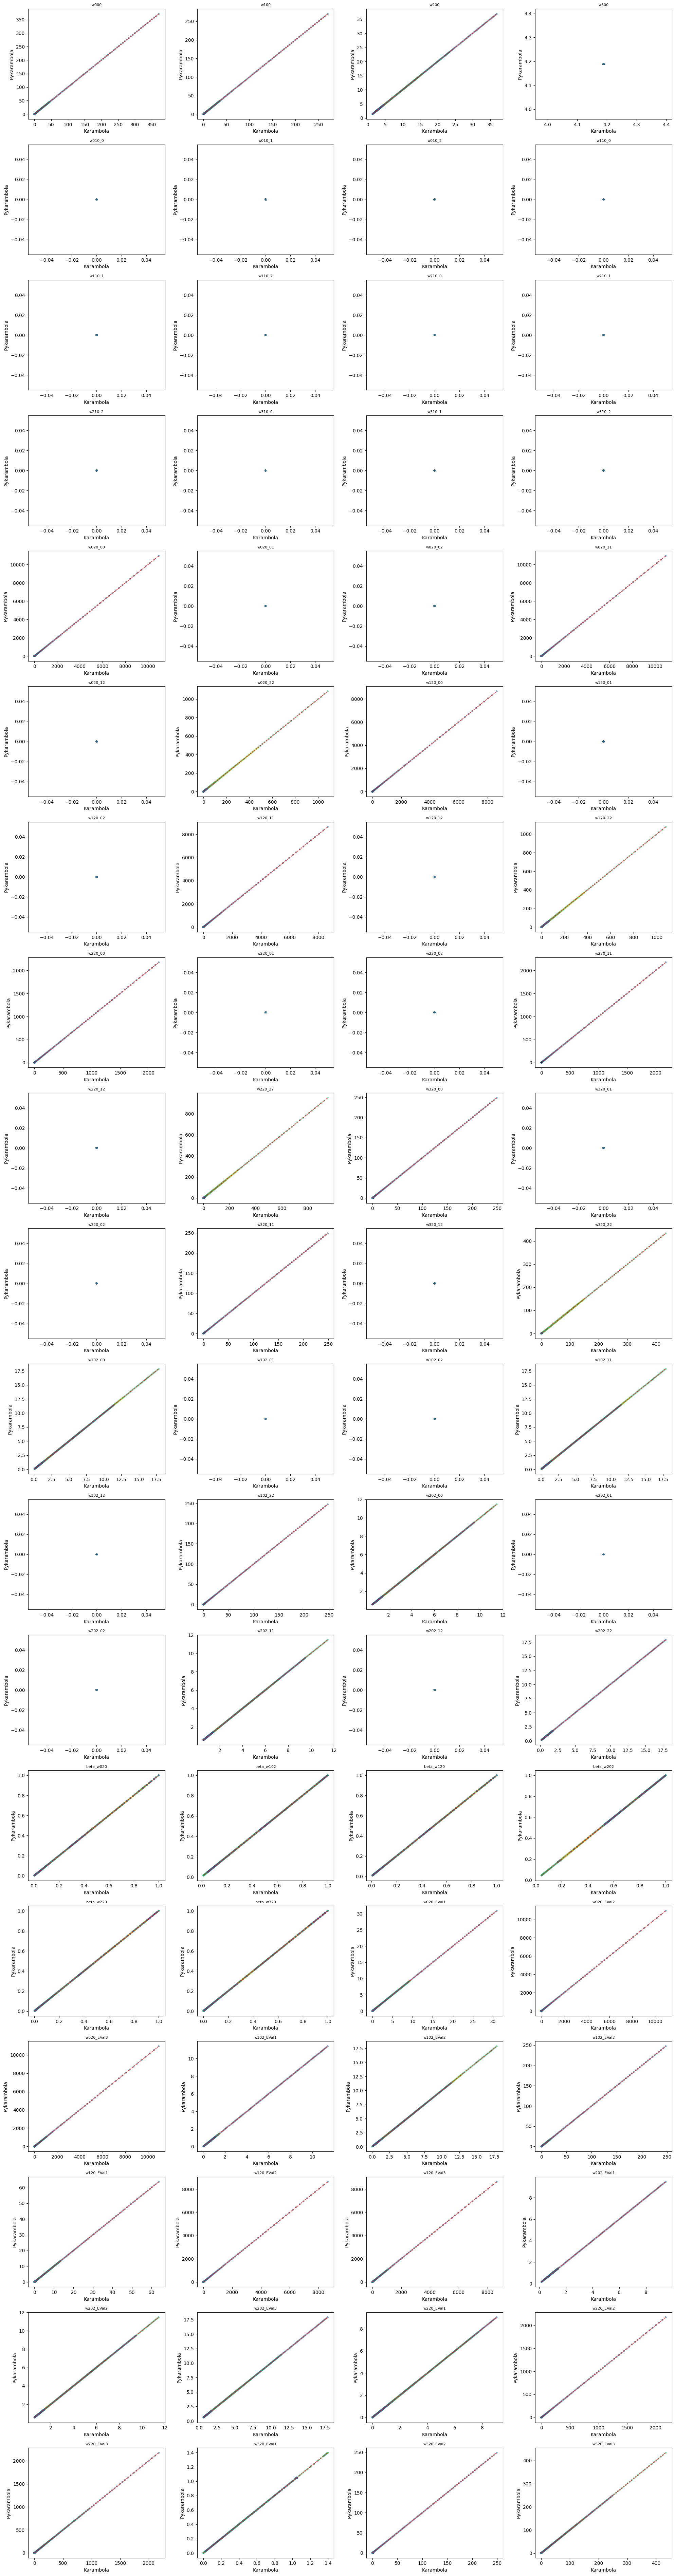

In [37]:
import matplotlib.pyplot as plt

n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flat

for ax, col in zip(axes, numeric_cols):
    x = df_merged[f'{col}_k']
    y = df_merged[f'{col}_py']
    ax.scatter(x, y, alpha=0.5, s=10, c=df_merged['label_mapped'].astype('category').cat.codes)
    # Perfect agreement line
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'r--', lw=1, label='y=x')
    ax.set_xlabel('Karambola'); ax.set_ylabel('Pykarambola')
    ax.set_title(col, fontsize=8)

for ax in axes:  # hide unused
    ax.set_visible(False)
plt.tight_layout()
plt.show()

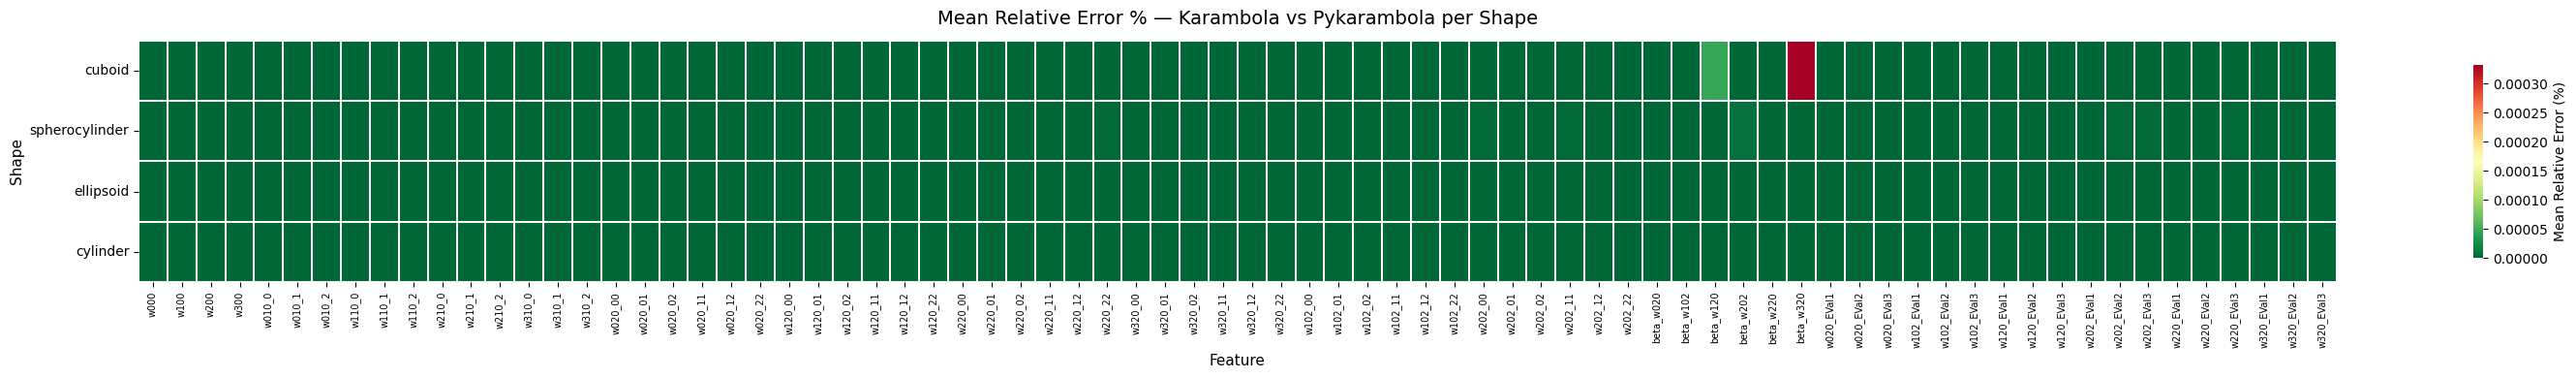

In [41]:
# ── Step 2: Define numeric columns to compare ────────────────────────────────
# Select only float columns from the original df (before merge added suffixes)
numeric_cols = df.select_dtypes(include='float').columns.tolist()

# ── Step 3: Compute mean relative error per (shape, column) ──────────────────
heatmap_data = []

ABS_THRESHOLD = 1e-11   # values smaller than this are treated as effectively zero

for shape in df_merged['label_mapped'].unique():
    mask = df_merged['label_mapped'] == shape
    row = {'shape': shape}

    for col in numeric_cols:
        k_vals  = df_merged.loc[mask, f'{col}_k']
        py_vals = df_merged.loc[mask, f'{col}_py']

        abs_diff = (k_vals - py_vals).abs()

        # Build denominator: use karambola magnitude, but NaN-out rows where
        # BOTH values are negligibly small (numerically zero — not meaningful)
        denom = k_vals.abs()
        both_negligible = (k_vals.abs() <= ABS_THRESHOLD) & (py_vals.abs() <= ABS_THRESHOLD)
        denom[both_negligible] = np.nan   # will be excluded from mean
        denom = denom.replace(0, np.nan)  # avoid division by exact zero

        rel_error = abs_diff / denom * 100
        row[col] = rel_error.mean()       # nanmean behaviour: ignores NaNs

    heatmap_data.append(row)

# ── Step 4: Build heatmap DataFrame ──────────────────────────────────────────
# Rows = shapes, Columns = features, Values = mean relative error %
heatmap_df = (
    pd.DataFrame(heatmap_data)
    .set_index('shape')
    .fillna(0)
)


# ── Step 5: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(30, 4))

seaborn.heatmap(
    heatmap_df,
    annot=False,            # no numbers printed inside cells
    cmap='RdYlGn_r',        # red = high error, green = low error
    linewidths=0.3,         # thin grid lines between cells
    ax=ax,
    cbar_kws={
        'label': 'Mean Relative Error (%)',   # legend label
        'shrink': 0.8,                         # slightly shrink the colorbar
    }
)

ax.set_title('Mean Relative Error % — Karambola vs Pykarambola per Shape',
             fontsize=14, pad=12)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Shape',   fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('../plots/heatmap_relative_error_with_vectorization_basic_shapes_aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

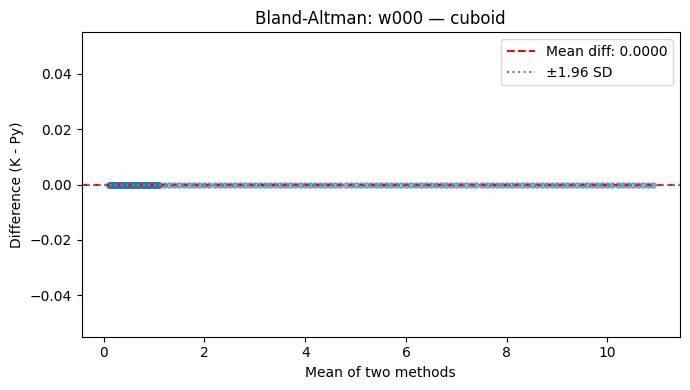

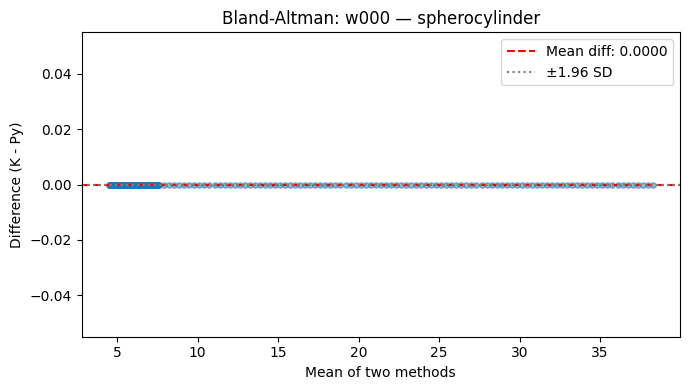

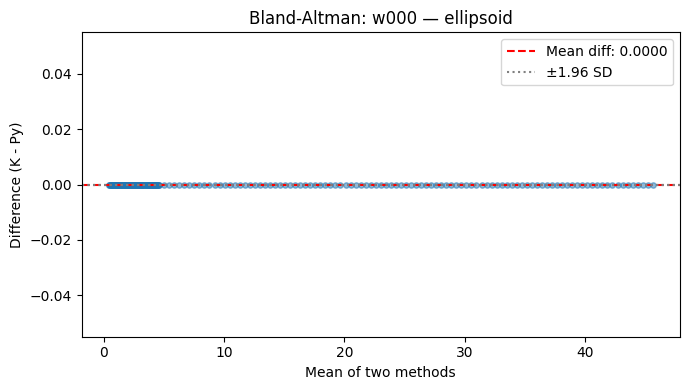

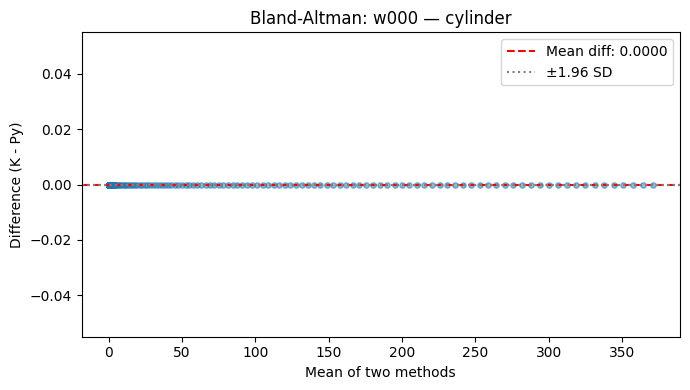

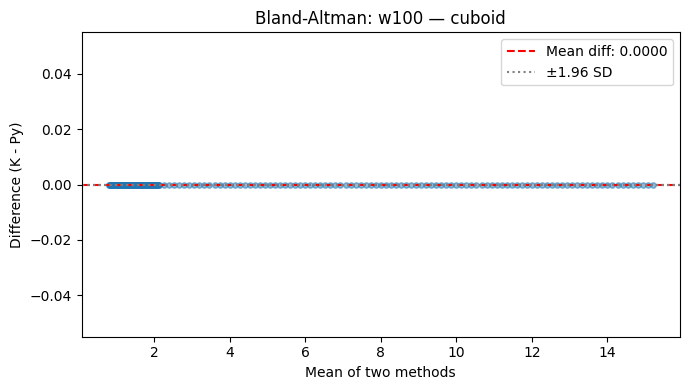

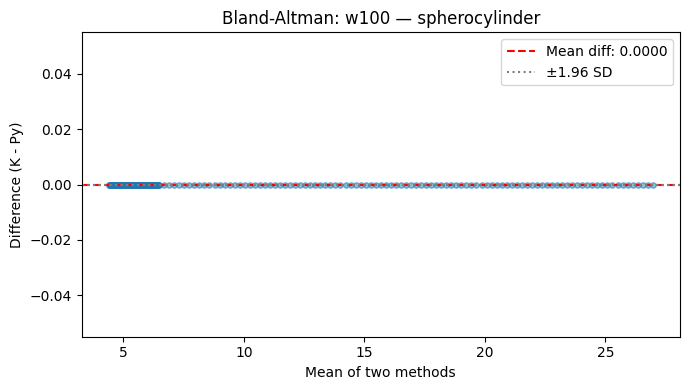

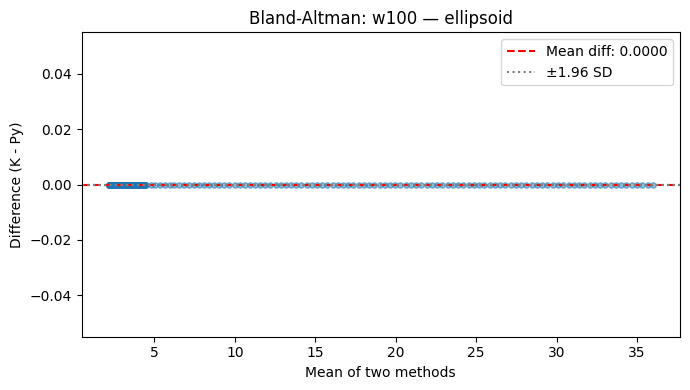

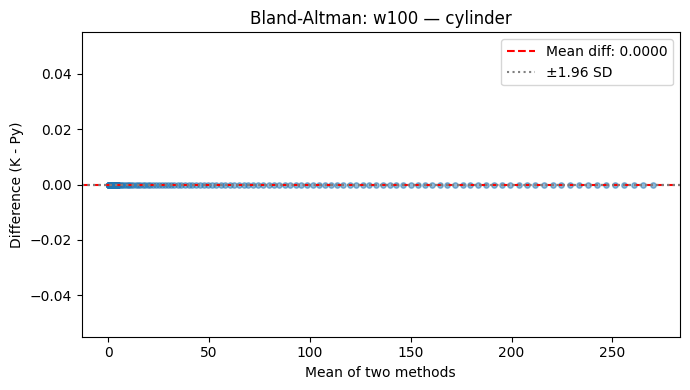

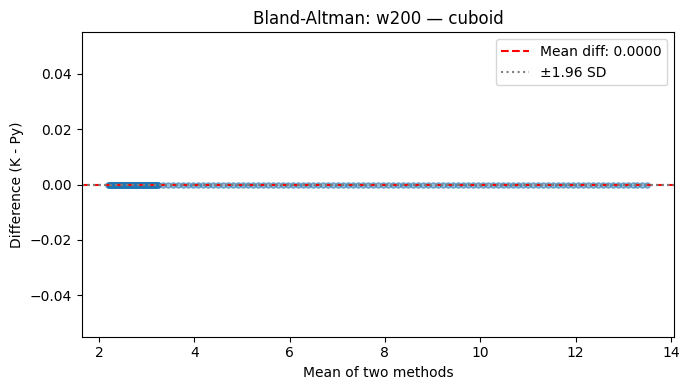

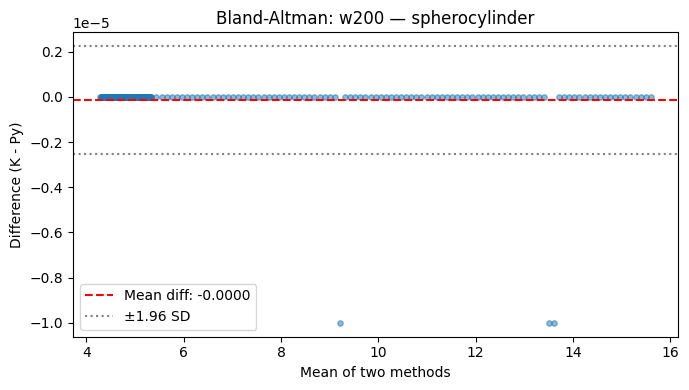

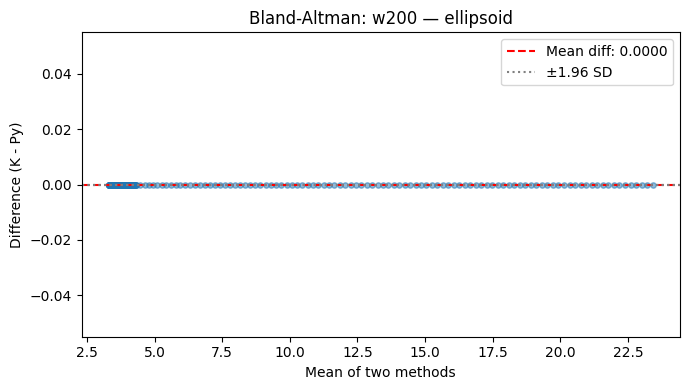

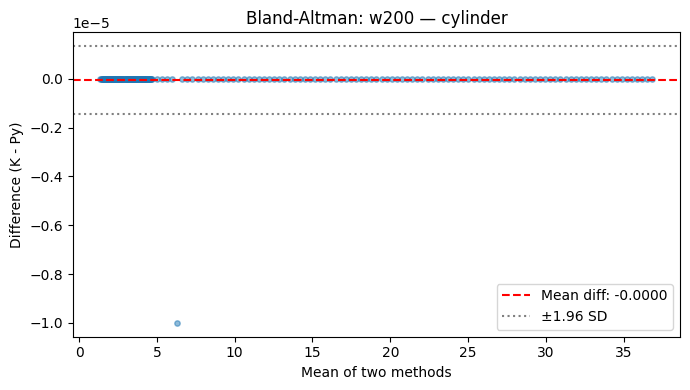

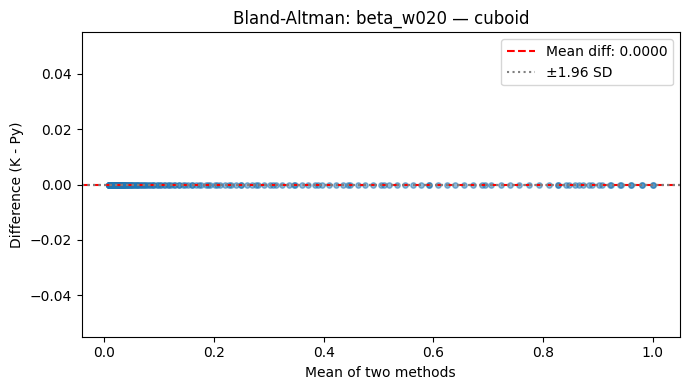

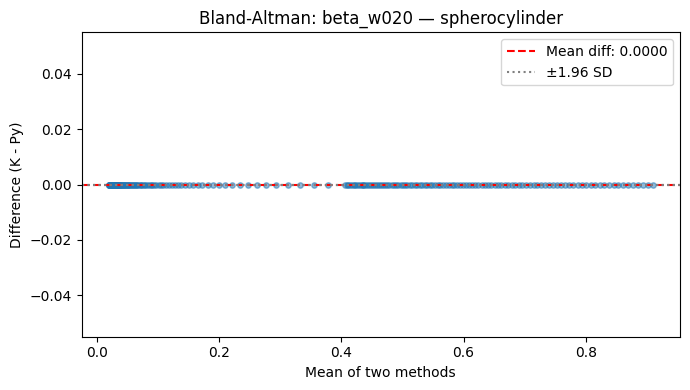

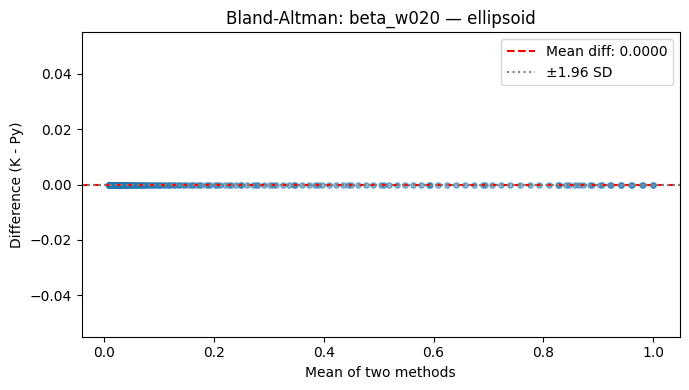

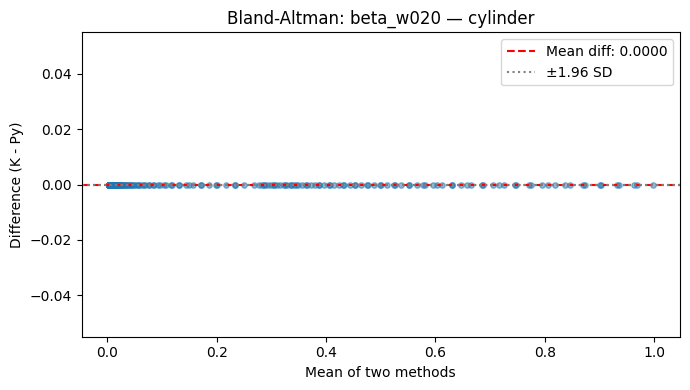

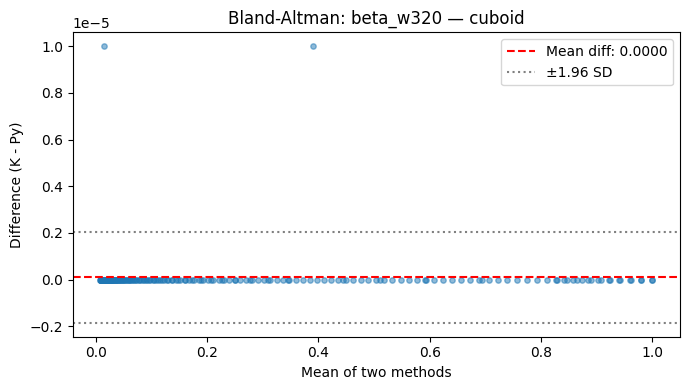

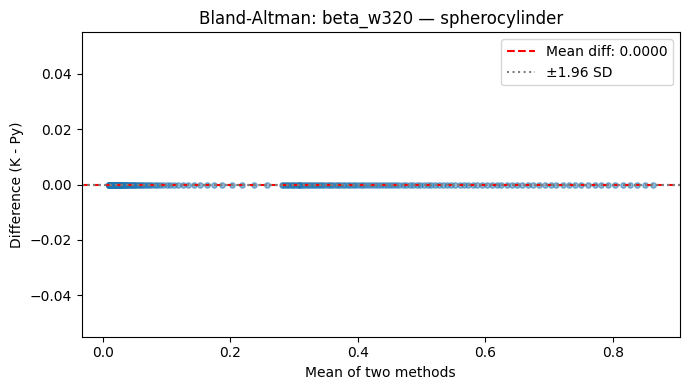

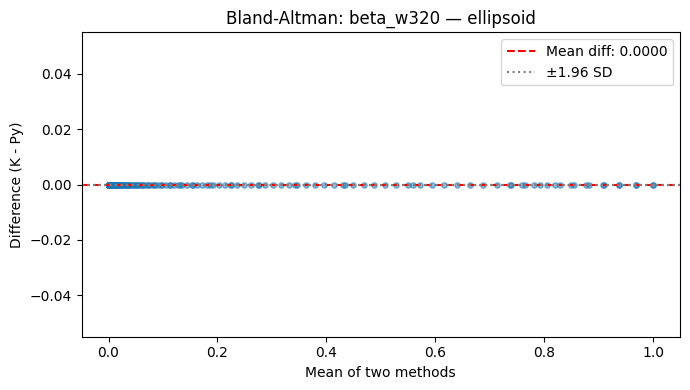

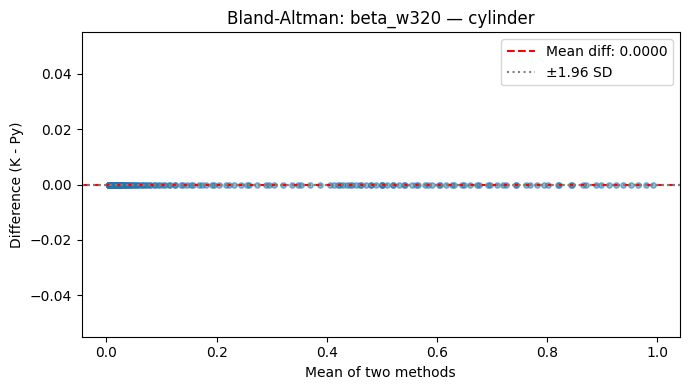

In [39]:
# Good for checking if disagreement grows with magnitude
for col in ['w000', 'w100', 'w200', 'beta_w020', 'beta_w320']:
    for shape in df_merged['label_mapped'].unique():
        subset = df_merged[df_merged['label_mapped'] == shape]

        k    = subset[f'{col}_k']
        py   = subset[f'{col}_py']
        mean = (k + py) / 2
        diff = k - py

        plt.figure(figsize=(7, 4))
        plt.scatter(mean, diff, alpha=0.5, s=15)
        plt.axhline(diff.mean(), color='red',   ls='--', label=f'Mean diff: {diff.mean():.4f}')
        plt.axhline(diff.mean() + 1.96*diff.std(), color='gray', ls=':', label='±1.96 SD')
        plt.axhline(diff.mean() - 1.96*diff.std(), color='gray', ls=':')
        plt.xlabel('Mean of two methods'); plt.ylabel('Difference (K - Py)')
        plt.title(f'Bland-Altman: {col} — {shape}'); plt.legend(); plt.tight_layout()
        plt.show()

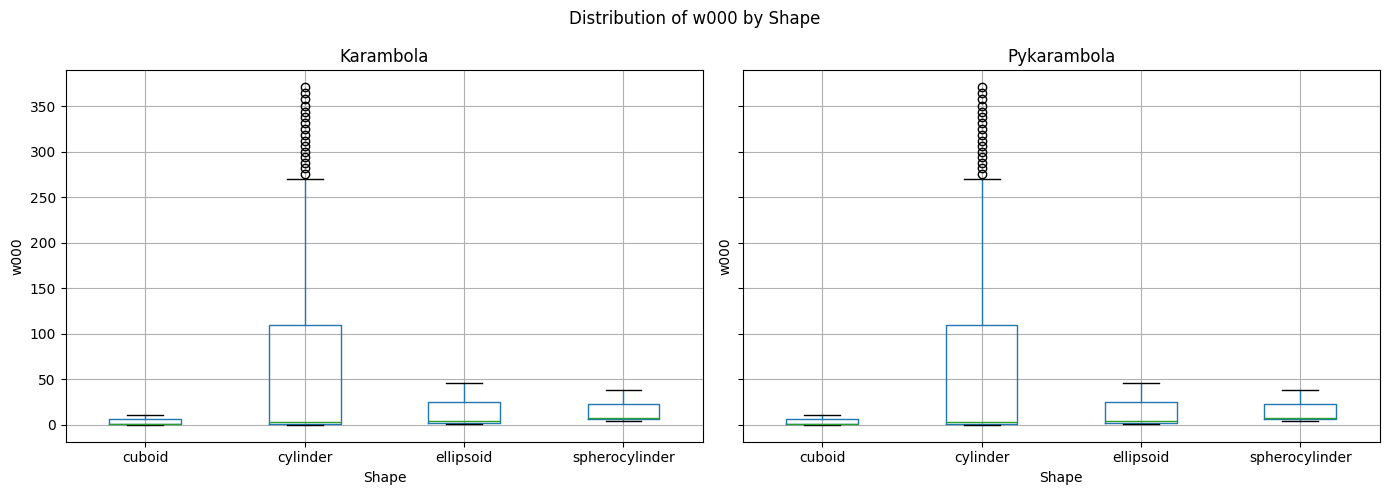

In [40]:
import matplotlib.pyplot as plt

col = 'w000'  # change to any column of interest

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (data, label) in zip(axes, [(df, 'Karambola'), (df_py, 'Pykarambola')]):
    data.boxplot(column=col, by='label_mapped', ax=ax)
    ax.set_title(label); ax.set_xlabel('Shape'); ax.set_ylabel(col)
plt.suptitle(f'Distribution of {col} by Shape')
plt.tight_layout()
plt.show()

# plots

In [11]:
import pandas
import matplotlib.pyplot as plt
import seaborn
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# import plotly.express as px

In [13]:
def reduced_vol(w000: float, w100: float):
    A = w100*3 # minkowski_tensors return A/3 as W_1 
    V = w000 # minkowski_tensors return V as W_0 
    return ((3*np.sqrt(4*np.pi))*V)/A**(3/2)

def reduced_imc(w200: float, w100: float):
    A = w100*3 # minkowski_tensors return A/3 as W_1 
    M = w200*3 # minkowski_tensors return M/3 as W_2 
    return M/np.sqrt(A/(4 * np.pi))

# Plot comparison time

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

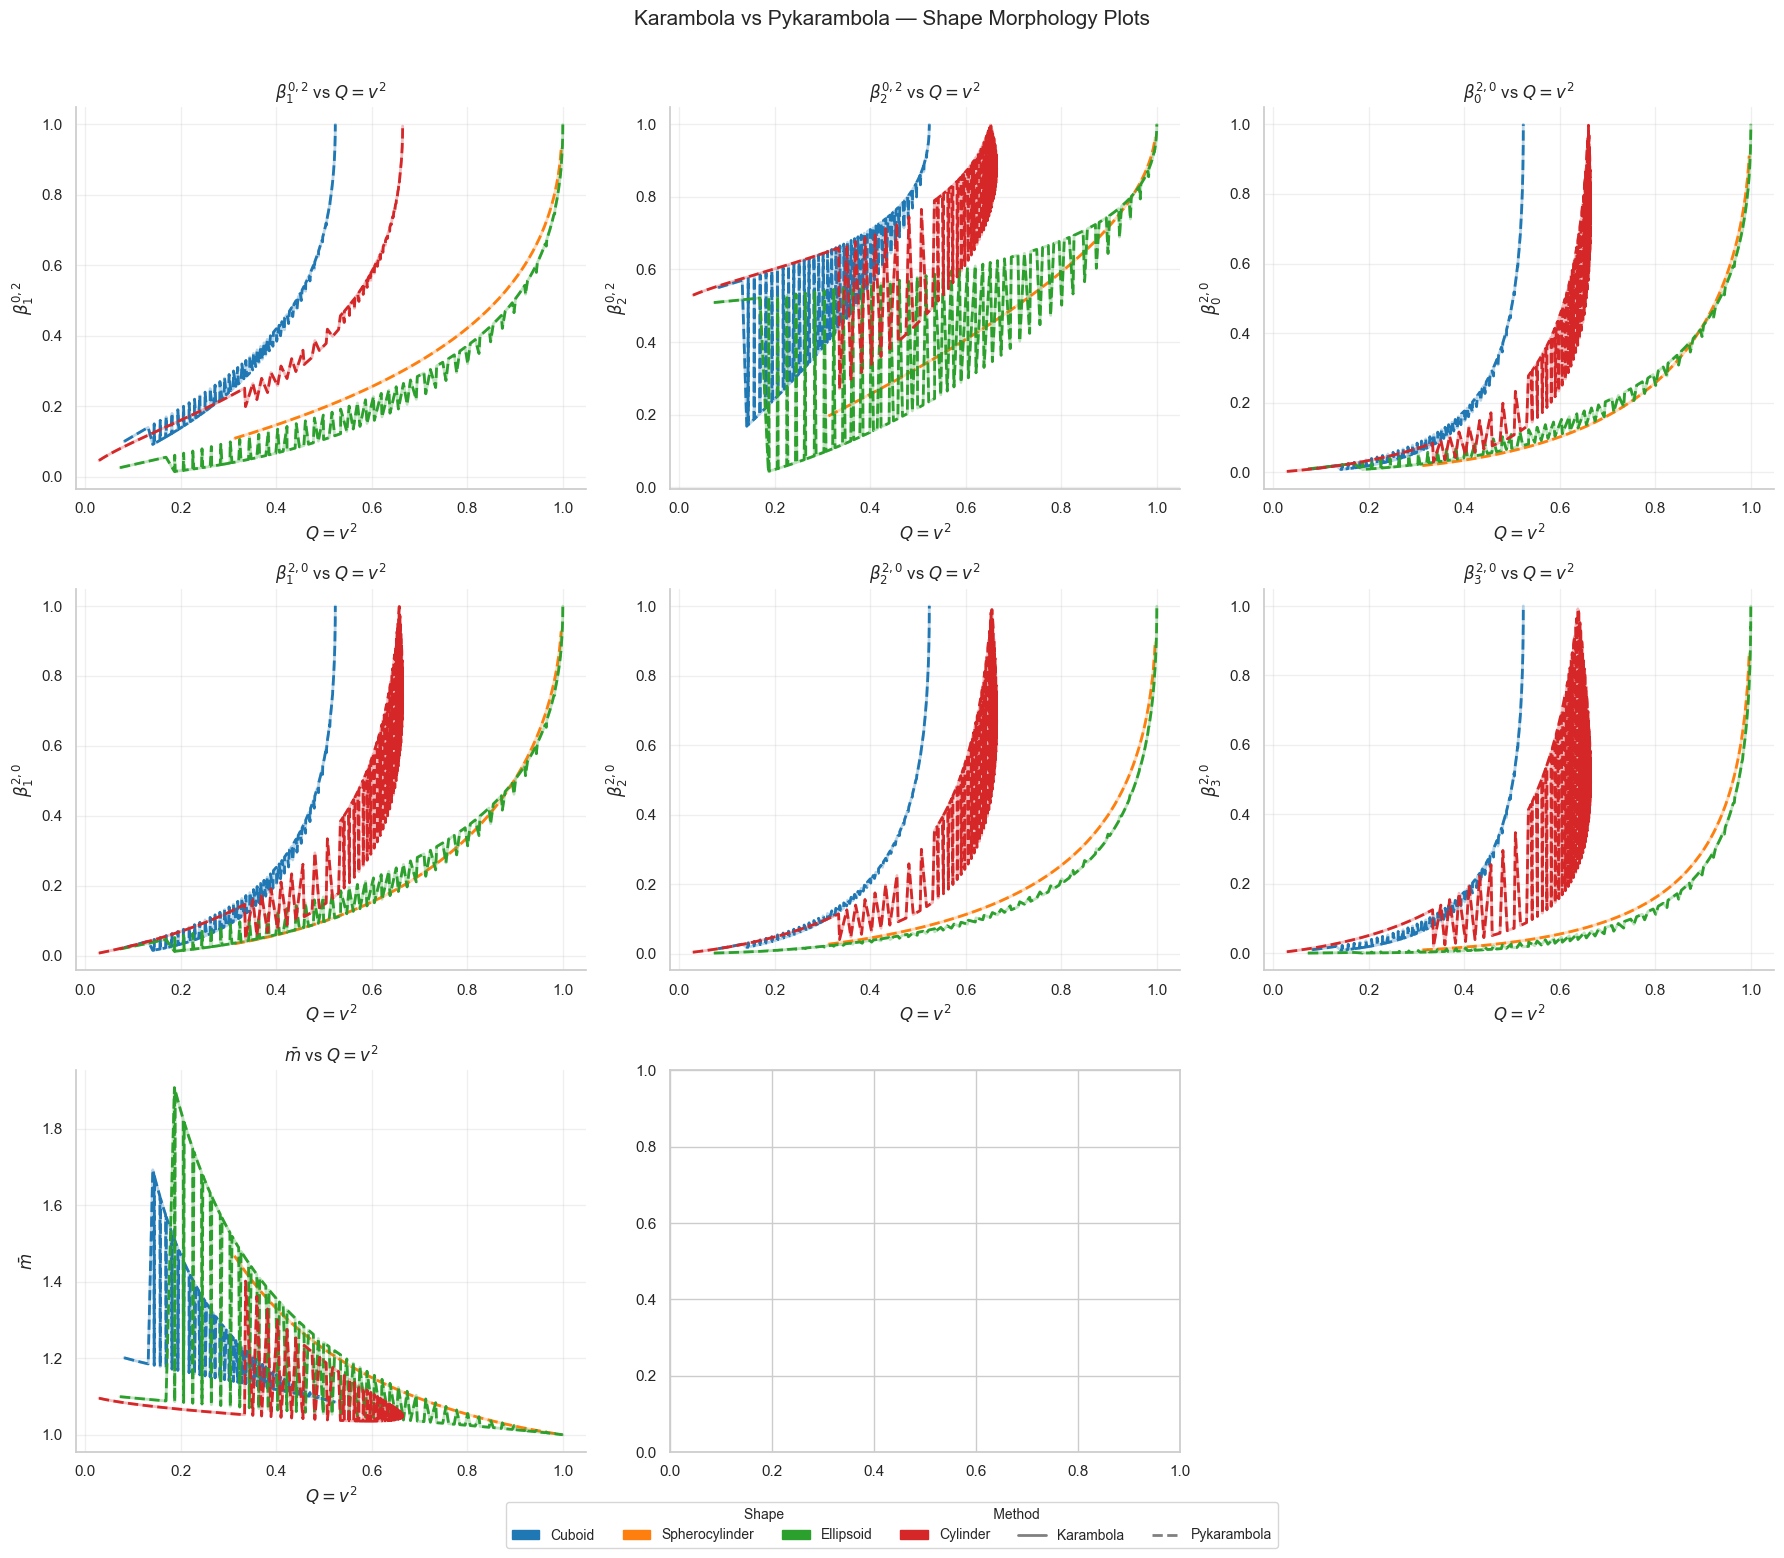

In [94]:


# ── Compute derived quantities for both DataFrames ───────────────────────────
for data in [df, df_py]:
    data['Q']     = reduced_vol(data['w000'], data['w100'])**2
    data['m_bar'] = reduced_imc(data['w200'], data['w100']) / (4 * np.pi)

# ── Plot config ───────────────────────────────────────────────────────────────
plots = [
    ('Q', 'beta_w102', r'$Q = v^2$', r'$\beta_1^{0,2}$'),
    ('Q', 'beta_w202', r'$Q = v^2$', r'$\beta_2^{0,2}$'),
    ('Q', 'beta_w020', r'$Q = v^2$', r'$\beta_0^{2,0}$'),
    ('Q', 'beta_w120', r'$Q = v^2$', r'$\beta_1^{2,0}$'),
    ('Q', 'beta_w220', r'$Q = v^2$', r'$\beta_2^{2,0}$'),
    ('Q', 'beta_w320', r'$Q = v^2$', r'$\beta_3^{2,0}$'),
    ('Q', 'm_bar',     r'$Q = v^2$', r'$\bar{m}$'),
]

shapes        = df['label_mapped'].unique()
shape_palette = dict(zip(shapes, sns.color_palette('tab10', len(shapes))))

ncols = 3
nrows = (len(plots) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
axes = axes.flat

for ax, (x_col, y_col, x_label, y_label) in zip(axes, plots):
    for shape in shapes:
        color = shape_palette[shape]

        dk  = df[df['label_mapped'] == shape].dropna(subset=[x_col, y_col]).sort_values(x_col)
        dpy = df_py[df_py['label_mapped'] == shape].dropna(subset=[x_col, y_col]).sort_values(x_col)

        # Karambola — solid line
        ax.plot(dk[x_col],  dk[y_col],
                color=color, linestyle='-', linewidth=2, alpha = 0.3)

        # Pykarambola — dashed line
        ax.plot(dpy[x_col], dpy[y_col],
                color=color, linestyle='--', linewidth=2)

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'{y_label} vs {x_label}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

# ── Hide unused axes ──────────────────────────────────────────────────────────
for ax in axes:
    ax.set_visible(False)

# ── Single shared legend ──────────────────────────────────────────────────────
shape_handles = [
    mpatches.Patch(color=shape_palette[s], label=s.capitalize())
    for s in shapes
]

method_handles = [
    mlines.Line2D([], [], color='gray', linestyle='-',  linewidth=2, label='Karambola'),
    mlines.Line2D([], [], color='gray', linestyle='--', linewidth=2, label='Pykarambola'),
]

fig.legend(
    handles=shape_handles + method_handles,
    loc='lower center',
    ncol=len(shapes) + 2,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
    title='Shape                                                      Method',
    title_fontsize=10,
)

plt.suptitle('Karambola vs Pykarambola — Shape Morphology Plots', fontsize=15, y=1.01)
plt.tight_layout()
# plt.savefig('comparison_morphology_plots.png', dpi=150, bbox_inches='tight')
plt.show()